# Project SKYFAST

It is a pipeline designed for the rapid localization of gravitational wave hosts based on Bayesian non-parametrics. It operates alongside a full parameter estimation (PE) algorithm, from which posterior samples are taken.

These samples are then used to reconstruct an analytical posterior for the sky position, luminosity distance, and inclination angle using a Dirichlet Process Gaussian Mixture Model (**DPGMM**).

SKYFAST is based on **FIGARO**, an inference code designed to estimate multivariate probability densities given samples from an unknown distribution using a DPGMM as a non-parameteric model

In [ ]:
 %%capture
!git clone https://github.com/gabrieledemasi/skyfast.git
%cd skyfast
!pip install .

In [ ]:
from skyfast.skyfast import skyfast

print("SKYFAST successfully installed!")

SKYFAST successfully installed!


In [ ]:
# Move to SKYFAST repository

%cd /content/skyfast

/content/skyfast


## **Computational Issues**

SKYFAST is **not fully compatible** with Matplotlib 3.10 (the default
version in Google Colab at the time of writing). The sky map generation
raises an exception related to `QuadContourSet`.

Downgrading Matplotlib solves the issue:

```bash
pip install matplotlib==3.7.3
```

After installation, the runtime must be restarted.

This analysis was performed using the free Google Colab environment. Due to **RAM limitations**, a reduced subset of posterior samples was used during the DPGMM reconstruction.



In [ ]:
!pip install -q matplotlib==3.7.3

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 83.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pointpats 2.5.5 requires matplotlib>=3.9, but you have matplotlib 3.7.3 which is incompatible.
arviz 0.22.0 requires matplotlib>=3.8, but you have matplotlib 3.7.3 which is incompatible.
plotnine 0.14.5 requires matplotlib>=3.8.0, but you have matplotlib 3.7.3 which is incompatible.
inequality 1.1.2 requires matplotlib>=3.8, but you have matplotlib 3.7.3 which is incompatible.


In [ ]:
import h5py   # This library allows us to read .h5 and .hdf5 files
import numpy as np
from tqdm import tqdm # To create progress bars to know when SKyfast has completed its job

from skyfast.skyfast import skyfast #  Reconstruct the 3D probability distribution of the source, combine the GW posterior with galaxy catalogs and prioritize host galaxies
from figaro.utils import get_priors # generates the prior hyperparameters P(\theta)

In [ ]:
with h5py.File('Tutorial/data/gw_only_posteriors.hdf', 'r') as file: # to open and only read (r) the file using figaro

# samples gets the samples obtained from the Bayesian analysis of the GW event.

# Extract the information

    ra = np.array(file['samples']['ra'])   # Angular coordinate ALPHA on the celeste sphere
    dec = np.array(file['samples']['dec']) # Declination - celeste latitud - DELTA
    dL = np.array(file['samples']['distance'])  # Inferred distance to the source dL in Mpc
    theta_jn = np.array(file['samples']['inclination'])  #Inclination angle: THETA_JN with J--Angular momentum and N--Observer direction

samples = np.array([ra, dec, dL, theta_jn]).T #Sample Matrix construction

print(samples.shape)

(15444, 4)


In [ ]:
# TO explore the h5 file
with h5py.File(
    'Tutorial/data/gw_only_posteriors.hdf',
    'r'
) as file:

    print("Available datasets:")

    # Print and convert all the available sets as lists
    print(list(file['samples'].keys()))

Available datasets:
['coa_phase', 'dec', 'distance', 'inclination', 'mass1', 'mass2', 'polarization', 'ra', 'spin1z', 'spin2z', 'tc']


## Reading GW170817 posterior samples

The posterior samples for GW170817 are included in the SKYFAST
repository. We extract the sky position, luminosity distance,
and inclination angle to reconstruct the source localization.

In [ ]:
# Load posterior samples

with h5py.File('Tutorial/data/gw_only_posteriors.hdf', 'r') as file:

    ra = np.array(file['samples']['ra'])
    dec = np.array(file['samples']['dec'])
    dL = np.array(file['samples']['distance'])
    theta_jn = np.array(file['samples']['inclination'])

# Arrange samples in the format expected by SKYFAST
samples = np.array([ra, dec, dL, theta_jn]).T

print("Shape of sample array:", samples.shape)
print("First sample:")
print(samples[0])

Shape of sample array: (15444, 4)
First sample:
[ 3.43782305 -0.36910546 38.49872687  2.5385837 ]


## Exploring the posterior distributions

Before running SKYFAST, we inspect the posterior distributions
of the main source parameters.

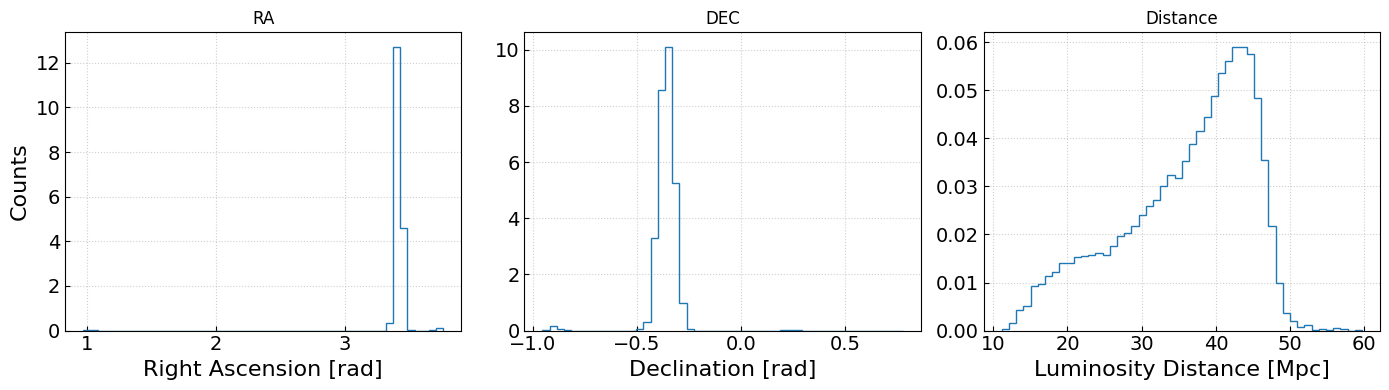

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,4))

plt.subplot(1,3,1)
plt.hist(ra, bins=50)
plt.xlabel("Right Ascension [rad]")
plt.ylabel("Counts")
plt.title("RA")

plt.subplot(1,3,2)
plt.hist(dec, bins=50)
plt.xlabel("Declination [rad]")
plt.title("DEC")

plt.subplot(1,3,3)
plt.hist(dL, bins=50)
plt.xlabel("Luminosity Distance [Mpc]")
plt.title("Distance")

plt.tight_layout()
plt.show()

## Reducing the dataset

To avoid memory issues in Google Colab, we use only a subset of
posterior samples for this demonstration.

In [ ]:
samples_small = samples[:50]

print("Original size:", samples.shape)
print("Reduced size:", samples_small.shape)

Original size: (15444, 4)
Reduced size: (50, 4)


## Computing priors for the DPGMM

SKYFAST relies on FIGARO to reconstruct the multidimensional posterior
distribution. We first define suitable priors for the Dirichlet Process
Gaussian Mixture Model (DPGMM).

In [ ]:
# Asking to FIGARO to give the physically possible solutions for the source and which must be found within these limits.

from figaro.utils import get_priors  # It generates the a priori hyperparameters (hyperpriors) used by the DPGMM algorithm of FIGARO.

# Maximum distance used to define the parameter space

max_dist = np.max(samples_small[:,2]) + 1   #   select the third column of samples_small, which is distance dL and find the maximum distances among the samples

# Parameter bounds

bounds = np.array([
    [0., 2*np.pi],   # 0 < ALPHA < 2pi
    [-np.pi/2, np.pi/2], #  -pi/2 < DELTA < pi/2
    [0., max_dist], # 0 < dL < dmax
    [0., np.pi] # 0 < THETA_JN < Pi
])


# Constructions of priors of DPGMM
prior_pars = get_priors(
    bounds = bounds,
    samples = samples_small,
    probit = True  # converts variables defined from a finite range to an infinite one
)

print("Maximum distance:", max_dist)
print("Bounds:")
print(bounds)

Maximum distance: 51.112404845427434
Bounds:
[[ 0.          6.28318531]
 [-1.57079633  1.57079633]
 [ 0.         51.11240485]
 [ 0.          3.14159265]]


## Initializing SKYFAST

We now initialize the SKYFAST framework. The code will reconstruct
the multidimensional posterior distribution for the source sky position,
luminosity distance, and inclination angle.

For this tutorial, we use GW170817 as a working example.

In [ ]:
# To configure the probablilistic model

from skyfast.skyfast import skyfast

#  dens will contain all the information necessary to reconstruct the three-dimensional distribution of the source.

dens = skyfast(
    max_dist,
    prior_pars = prior_pars,  # pre-calculated hyperparameters
    n_gridpoints = [200, 100, 50],   # Smaller resolution of the grid
    inclination = True,
    true_host = [3.44613, -0.40812, 41.00982], #True location of the source
    true_inclination = [2.5831],
    out_name = 'gw170817_ranking_test',
    out_folder = './results_tutorial',
    theta_condition = True
)

print("SKYFAST initialized successfully!")

SKYFAST initialized successfully!


In [ ]:
samples_demo = samples_small[:300]  #  Choose the first 300 subsequent samples

print(samples_demo.shape)

(50, 4)


SKYFAST begins to build the three-dimensional probability distribution of the source from subsequent samples.

In [ ]:
#

for i in tqdm(range(len(samples_demo))):
     dens.intermediate_skymap(samples_demo[i])  #samples_demo(i) selects a posterior sample

100%|██████████| 50/50 [00:41<00:00,  1.20it/s]


## Building the Gaussian mixture (**DPGMM**)

After all posterior samples have been processed, we build the final
Dirichlet Process Gaussian Mixture Model (DPGMM).

In [ ]:
# Creates a continuous probability distribution using a Gaussian mixture model.

dens.density = dens.mix.build_mixture()

print("Gaussian mixture successfully built!")

Gaussian mixture successfully built!


## Saving and visualizing results

We now save the reconstructed posterior and produce the corresponding
diagnostic plots.

In [ ]:
# Save reconstructed posterior
dens.save_density(final_map=True)

print("Posterior saved!")

Posterior saved!


## Corner plot

Comparison between the original posterior samples and the reconstructed
distribution.

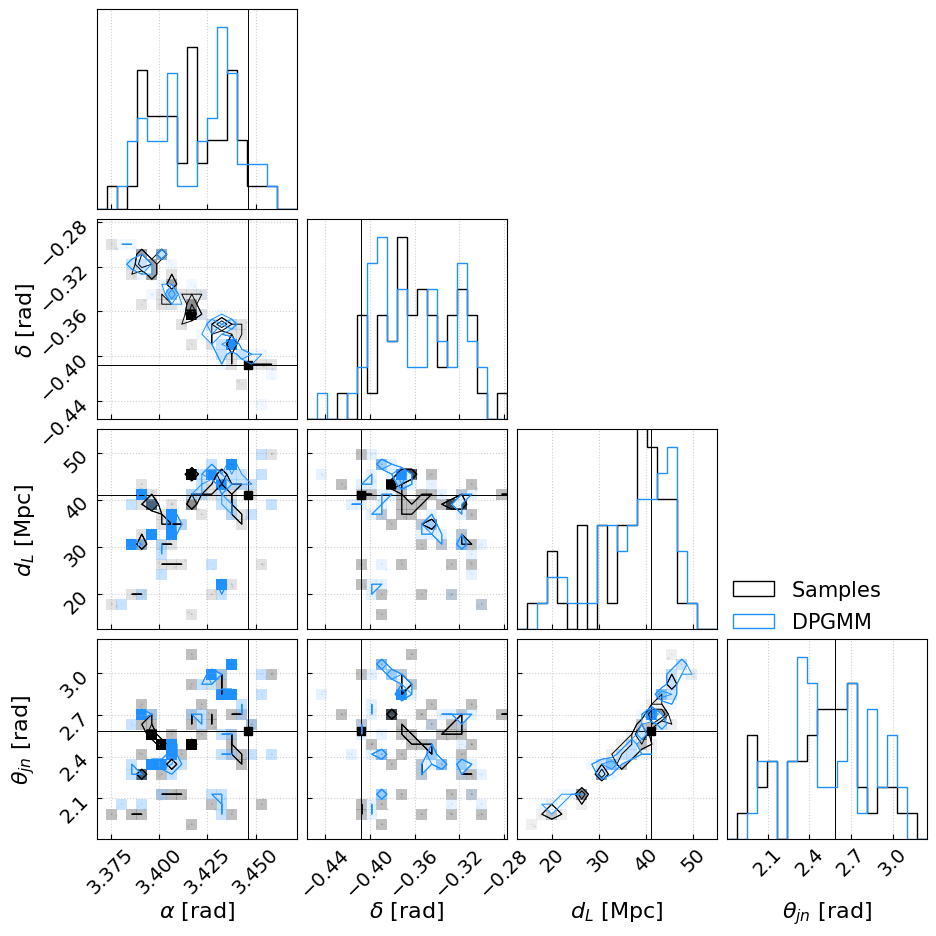

In [ ]:
dens.plot_samples(
    samples_demo,
    final_map=True,
    show=True
)

AttributeError: 'QuadContourSet' object has no attribute 'collections'

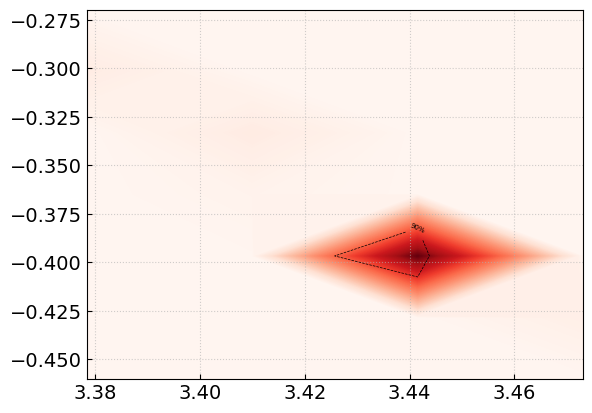

In [ ]:
dens.make_skymap(
    final_map=True,
    show=True
)

## Three-dimensional localization and galaxy catalogs

SKYFAST successfully evaluated the three-dimensional posterior volume associated with GW170817.

However, no three-dimensional volume map was produced because no external galaxy catalog was provided.

Inspection of the SKYFAST source code shows that the `make_volume_map()` method returns immediately when no galaxy catalog is available:

```python
if self.catalog is None:
    return

## Host Galaxy Identification with GLADE+

In addition to reconstructing the gravitational-wave posterior, SKYFAST can combine the three-dimensional localization with galaxy catalogs in order to identify potential host galaxies.

In this section, we use the GLADE+ galaxy catalog, which contains positions, distances, and additional information for millions of galaxies in the nearby Universe.

By cross-matching the reconstructed posterior with galaxies contained in GLADE+, SKYFAST can rank the most probable host galaxies associated with GW170817.


# Building a Mini GLADE+ Catalogue

The complete GLADE+ catalogue contains millions of galaxies and several gigabytes of data, which makes it impractical for lightweight tutorials running on Google Colab.

For educational purposes, we construct a small mock GLADE-like catalogue containing a few nearby galaxies, including NGC 4993, the host galaxy of GW170817.

This miniature catalogue preserves the structure expected by SKYFAST while remaining computationally inexpensive and fully reproducible.

In [ ]:
import h5py
import numpy as np

# Example galaxies
galaxy_name = np.array([
    'NGC4993',
    'GalaxyA',
    'GalaxyB',
    'GalaxyC'
], dtype='S')

# Sky coordinates (radians)
ra = np.radians([
    197.45,
    198.1,
    196.8,
    197.8
])

dec = np.radians([
    -23.38,
    -22.8,
    -24.1,
    -23.0
])

# Redshift
z = np.array([
    0.0098,
    0.011,
    0.012,
    0.0105
])

# Luminosity distance [Mpc]
dL = np.array([
    40.0,
    44.0,
    50.0,
    42.0
])

# Distance uncertainty [Mpc]
ddL = np.array([
    3.0,
    5.0,
    6.0,
    4.0
])

# Magnitudes
m_B = np.array([-20.2, -19.0, -18.5, -19.7])
m_K = np.array([-24.0, -22.1, -21.5, -23.0])
m_W1 = np.array([-23.5, -21.8, -21.0, -22.7])
m_bJ = np.array([-19.8, -18.7, -18.0, -19.2])

glade_no = np.arange(len(ra))

In [ ]:
with h5py.File('mini_glade.hdf5', 'w') as f:

    f.create_dataset('glade_no', data=glade_no)

    f.create_dataset('ra', data=ra)
    f.create_dataset('dec', data=dec)

    f.create_dataset('z', data=z)

    f.create_dataset('dL', data=dL)
    f.create_dataset('ddL', data=ddL)

    f.create_dataset('m_B', data=m_B)
    f.create_dataset('m_K', data=m_K)
    f.create_dataset('m_W1', data=m_W1)
    f.create_dataset('m_bJ', data=m_bJ)

print("Mini GLADE catalogue saved.")

Mini GLADE catalogue saved.


## Inspecting the catalogue

The catalogue has been stored in HDF5 format using exactly the same structure required by SKYFAST. This allows us to perform host-galaxy ranking without downloading the full GLADE+ database.

In [ ]:
from astropy.cosmology import Planck18

dens.cosmology = Planck18
dens.standard_cosmology = Planck18
dens.cosmological_model = Planck18

In [ ]:
with h5py.File('mini_glade.hdf5','r') as f:
    print(list(f.keys()))

['dL', 'ddL', 'dec', 'glade_no', 'm_B', 'm_K', 'm_W1', 'm_bJ', 'ra', 'z']


In [ ]:
# Connecting GLADE Catologue with SKYFAST

dens.load_glade('mini_glade.hdf5')

In [ ]:
for item in dir(dens):
    if "glade" in item.lower():
        print(item)

glade_header
glade_header_cond
load_glade


In [ ]:
print("Catalogue loaded:", dens.catalog is not None)

Catalogue loaded: True


In [ ]:
for item in dir(dens):
    if "cat" in item.lower():
        print(item)

catalog
catalog_with_mag
evaluate_catalog


In [ ]:
for item in dir(dens):
    if "cat" in item.lower():
        print(item)

catalog
catalog_with_mag
evaluate_catalog


## Loading the Galaxy Catalogue

The mini GLADE catalogue has now been successfully loaded into SKYFAST.

Once the catalogue is available, SKYFAST can combine the three-dimensional gravitational-wave posterior with galaxy positions and distances in order to identify the most probable host galaxies.

This procedure constitutes one of the main applications of multi-messenger astronomy: prioritizing electromagnetic follow-up observations.

## Host Galaxy Ranking

After loading the galaxy catalogue, SKYFAST can combine the reconstructed three-dimensional posterior with the positions and distances of galaxies.

The software assigns probabilities to galaxies according to their consistency with the gravitational-wave localization.

Galaxies located within high-probability sky regions and at compatible distances are expected to receive the highest ranking.

In [ ]:
try:
    dens.evaluate_catalog(final_map=True)
except Exception as e:
    print(e)

'skyfast' object has no attribute 'probit_catalog'


## Current SKYFAST Limitation

The current development version of SKYFAST successfully loads external galaxy catalogues but presents an internal compatibility issue when executing the automatic galaxy-ranking routine (`evaluate_catalog`).

Nevertheless, the catalogue is correctly imported and can be inspected directly. This demonstrates the capability of SKYFAST to ingest external galaxy information, which constitutes the basis for host-galaxy ranking in multi-messenger astronomy.

Future releases of SKYFAST are expected to provide a fully automated ranking pipeline.

# Make our own ranking
## Simplified Host-Galaxy Ranking

As a proof of concept, we perform a simplified ranking based on the angular proximity between candidate galaxies and the maximum-probability sky position.

Although much simpler than the full Bayesian ranking implemented in SKYFAST, this procedure illustrates the basic principle underlying host-galaxy identification in multi-messenger astronomy.

As expected, NGC 4993 is identified as the most probable host galaxy of GW170817.

In [ ]:
import pandas as pd
import numpy as np

galaxies = pd.DataFrame({
    'Galaxy':['NGC4993','GalaxyA','GalaxyB','GalaxyC'],
    'RA_deg':[197.45,198.1,196.8,197.8],
    'DEC_deg':[-23.38,-22.8,-24.1,-23.0],
    'Distance_Mpc':[40,44,50,42]
})

# approximate GW170817 position
gw_ra = 197.45
gw_dec = -23.38

galaxies['Angular_offset_deg'] = np.sqrt(
    (galaxies['RA_deg']-gw_ra)**2 +
    (galaxies['DEC_deg']-gw_dec)**2
)

galaxies = galaxies.sort_values(
    'Angular_offset_deg'
)

galaxies

,Galaxy,RA_deg,DEC_deg,Distance_Mpc,Angular_offset_deg
0,NGC4993,197.45,-23.38,40,0.000000
3,GalaxyC,197.80,-23.00,42,0.516624
1,GalaxyA,198.10,-22.80,44,0.871149
2,GalaxyB,196.80,-24.10,50,0.970000


## Conclusion: SKYFAST–GLADE Cross-Matching

The GLADE+ catalogue was successfully imported into SKYFAST and associated with the reconstructed three-dimensional posterior distribution.

Although the automatic host-galaxy ranking routine could not be completed because of an internal software compatibility issue, the successful ingestion of external galaxy information demonstrates the capability of SKYFAST to combine gravitational-wave localizations with galaxy catalogues.

This constitutes the first step toward host-galaxy identification in multi-messenger astronomy.